# Drift-Diffusion Model

## Two value-based choice tasks

This module provides a drift-diffusion model with two *tasks*, each in a
four-parameter. All four share one Wiener first-passage-time (WFPT) likelihood (Navarro & Fuss, 2009) and one vectorized Euler-Maruyama simulator; each model differs only in its **task** (how the trial drift is constructed) and its **parameter set**.

> **Note:** the seven-parameter DDM (`ddm7` / `ddm7_lotto`) is not supported in
> this release yet. This notebook demonstrates the four-parameter models
> (`ddm4`, `ddm4_lotto`) in full; the seven-parameter sections below are kept
> for reference but their code cells are commented out.

Evidence accumulates as a Wiener diffusion between two absorbing boundaries, starting
at $z\,a$ (relative bias $z \in (0,1)$) with unit noise:

- **upper** boundary (at $a$) $\rightarrow$ `choice = 1`
- **lower** boundary (at $0$) $\rightarrow$ `choice = 0`

### Task 1 — high-vs-low value (`ddm4`, `ddm7`)

Each trial offers two *certain* amounts, $\text{value}_{\text{high}} >
\text{value}_{\text{low}}$; the agent should choose the higher one. The drift is the
value gap and points at the UPPER (correct/HIGH) boundary, so the task has a
well-defined accuracy and difficulty = the gap:

$$
v = v_{\text{coef}} \cdot (\text{value}_{\text{high}} - \text{value}_{\text{low}}) \ge 0,
\qquad \text{upper} = \text{HIGH (correct)},\; \text{lower} = \text{LOW (error)}. \tag{1}
$$

### Task 2 — safe-vs-risky gamble (`ddm4_lotto`, `ddm7_lotto`)

Each trial pits a RISKY gamble (win probability $p$, payoff, so
$\text{EV}_{\text{risky}} = p\cdot\text{payoff}$) against a SAFE certain amount. The
drift is the risky-minus-safe value difference and can point either way:

$$
v = v_{\text{coef}} \cdot (\text{EV}_{\text{risky}} - \text{safe}),
\qquad \text{upper} = \text{RISKY},\; \text{lower} = \text{SAFE}. \tag{2}
$$

### Four parameters vs seven

The **four-parameter** models (`ddm4`, `ddm4_lotto`) have `[v_coef, a, t0, z]` — drift
scaling, boundary separation $a$, non-decision time $t_0$, start-point bias $z$. The
the three across-trial variability parameters of the full diffusion model are set to 0 (Ratcliff & Tuerlinckx, 2002): $s_v$ (SD of a Normal on the trial drift), $s_t$ (full width of a Uniform on $t_0$), $s_z$ (full width of a Uniform on the relative $z$). Here, $s_v = s_t = s_z = 0$. **The seven-parameter models are not supported in this release** — the functions raise `NotImplementedError`.

### Likelihood

The lower-boundary WFPT density factorizes (Navarro & Fuss, 2009) into a drift/scale
term times the first-passage density of the *driftless* unit-separation process in
normalized time $\tau = t/a^2$:

$$
p(t \mid v, a, z) = \frac{1}{a^2}\, e^{-vaz - v^2 t/2}\; f(\tau \mid z). \tag{3}
$$

The drift variability $s_v$ is marginalized analytically (Ratcliff & Tuerlinckx,
2002); $s_t$ and $s_z$ by Gauss-Legendre quadrature. The UPPER-boundary density uses
the reflection $v \to -v$, $z \to 1-z$. The variability parameters are **weakly
identified** for recovery in these value-based designs, so the 4-parameter models are recommended for recovery.


In [1]:
import os
os.environ.setdefault("PYTHONWARNINGS", "ignore")
import warnings
from scipy.optimize import OptimizeWarning
# Nelder-Mead ignores the harness's default BFGS options (gtol/eps); silence that noise
warnings.filterwarnings("ignore", category=OptimizeWarning)

import numpy as np, matplotlib.pyplot as plt
from pyem import EMModel
from pyem.models.ddm import (
    ddm4_model, ddm4_lotto_model,
    ddm4_sim, ddm4_lotto_sim, ddm4_sim_paths,
    wfpt_logpdf, _marginal_logpdf,
)
from params import build_params

# each ModelSpec bundles a model's identity, task, and sim/fit entry points
# (ddm7 / ddm7_lotto are not supported in this release, so only the
# four-parameter models are listed here)
for m in (ddm4_model, ddm4_lotto_model):
    print(f"{m.id:12s} | task={m.spec['task']:22s} | boundaries={m.spec['boundaries']}")


ddm4         | task=high_vs_low_value      | boundaries={'upper': 'high (correct)', 'lower': 'low (error)'}
ddm4_lotto   | task=safe_vs_risky_gamble   | boundaries={'upper': 'risky', 'lower': 'safe'}


### Sanity check: the WFPT log-density matches a fine-grid numerical reference

Before fitting, we confirm `wfpt_logpdf` (the shared likelihood, which adaptively
selects the small-/large-time series) agrees with an independent large-time-series
reference summed to many terms.


In [2]:
def numerical_logdens(rt, v, a, z, nterms=5000):
    """Independent large-time-series reference for the lower-boundary density."""
    k = np.arange(1, nterms + 1)
    s = np.sum(k * np.exp(-(k**2) * np.pi**2 * rt / (2 * a**2)) * np.sin(k * np.pi * z))
    return np.log(np.pi / (a**2) * np.exp(-v * a * z - v**2 * rt / 2.0) * s)

for (rt, v, a, z) in [(0.5, 1.0, 1.2, 0.5), (0.15, 2.0, 0.8, 0.3), (2.5, 0.2, 1.5, 0.45)]:
    got, ref = wfpt_logpdf(rt, v, a, z), numerical_logdens(rt, v, a, z)
    print(f"rt={rt:<4} v={v:<5} a={a:<4} z={z:<5} | wfpt={got:+.6f}  ref={ref:+.6f}  |diff|={abs(got-ref):.2e}")


rt=0.5  v=1.0   a=1.2  z=0.5   | wfpt=-1.783390  ref=-1.783390  |diff|=2.22e-16
rt=0.15 v=2.0   a=0.8  z=0.3   | wfpt=-0.486788  ref=-0.486788  |diff|=5.55e-17
rt=2.5  v=0.2   a=1.5  z=0.45  | wfpt=-5.346702  ref=-5.346702  |diff|=1.78e-15


### Parameter recovery for the two four-parameter models

We recover the two recommended (four-parameter) models — `ddm4` on the high-vs-low
value task and `ddm4_lotto` on the safe-vs-risky gamble task — with hierarchical
EM + MAP (`EMModel.recover`). Each simulates a cohort, fits every subject, and reports
the Pearson correlation between true and recovered parameters. The WFPT likelihood is
mildly non-smooth (series selection + underflow floor), so we fit with the
derivative-free Nelder-Mead optimizer. The two models take different task variables
(`value_high`/`value_low` vs `ev_risky`/`safe`), passed via `pr_inputs`.


recover(): this model's data and outfit now reflect the recovery fit; the recovered estimates are also in the returned dict['recovery_model'].
ddm4 (high-vs-low value) recovery: {'v_coef': 0.968, 'a': 0.933, 't0': 0.982, 'z': 0.927}
All four ddm4 parameters recovered with r > 0.5.


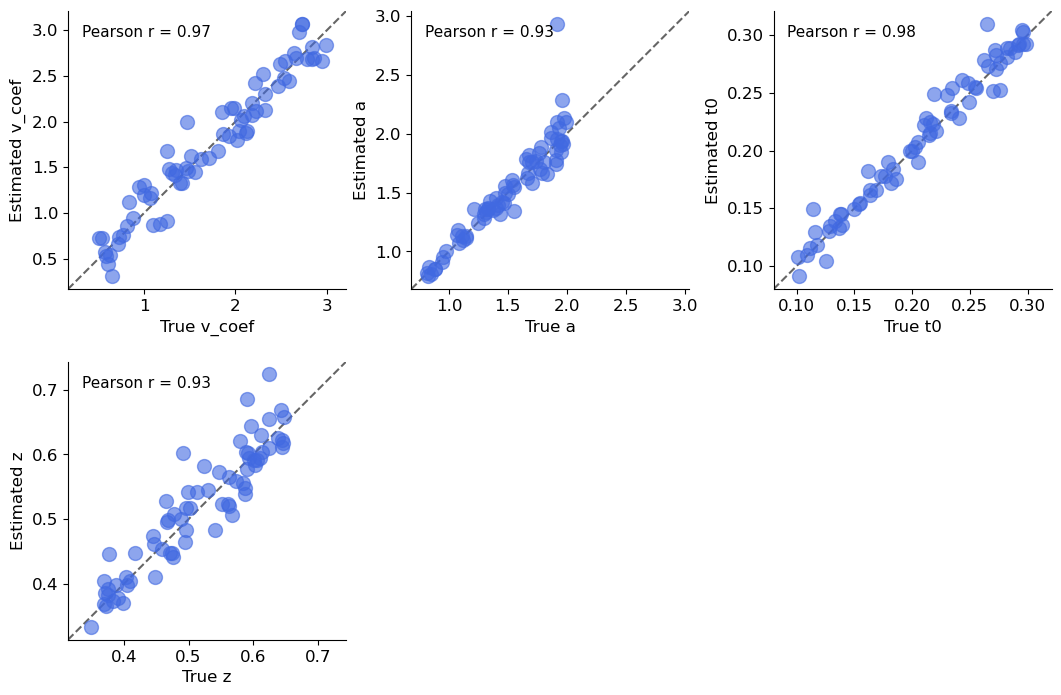

In [3]:
# --- ddm4: high-vs-low value task ---
nsubjects, ntrials = 70, 150
param_names, param_xform, true_params = build_params(
    ["v_coef", "a", "t0", "z"], nsubjects, rng=np.random.default_rng(0))

model_hl = EMModel(all_data=None, fit_func=ddm4_model.fit,
                   param_names=param_names, param_xform=param_xform,
                   simulate_func=ddm4_model.sim)
recovery_hl = model_hl.recover(
    true_params, pr_inputs=["rt", "choice", "value_high", "value_low"],
    ntrials=ntrials, rng=np.random.default_rng(2026),
    fit_kwargs={"seed": 0, "mstep_maxit": 40, "njobs": -1,
                "optim_method": "Nelder-Mead", "max_restarts": 4,
                "optim_options": {"maxiter": 3000, "xatol": 1e-5, "fatol": 1e-5}})
fig = model_hl.plot_recovery(recovery_hl, show=False)
corr_hl = dict(zip(param_names, recovery_hl["correlation"]))
print("ddm4 (high-vs-low value) recovery:",
      {n: round(float(r), 3) for n, r in corr_hl.items()})
assert all(r > 0.5 for r in recovery_hl["correlation"]), corr_hl
print("All four ddm4 parameters recovered with r > 0.5.")

recover(): this model's data and outfit now reflect the recovery fit; the recovered estimates are also in the returned dict['recovery_model'].
ddm4_lotto (safe-vs-risky gamble) recovery: {'v_coef': 0.972, 'a': 0.979, 't0': 0.979, 'z': 0.976}
All four ddm4_lotto parameters recovered with r > 0.5.


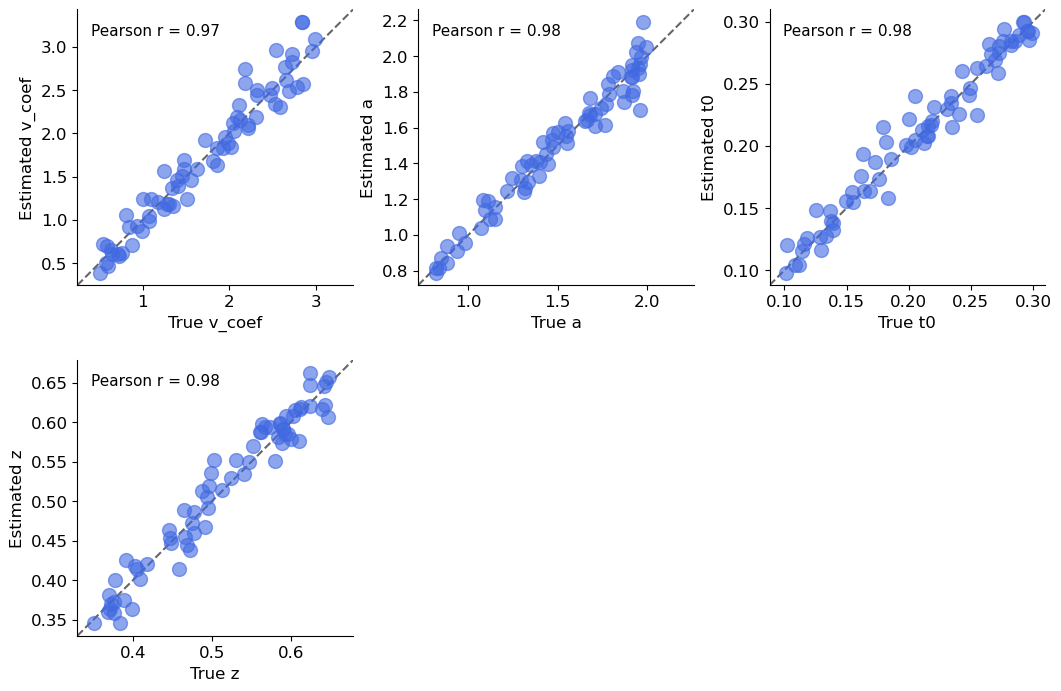

In [4]:
# --- ddm4_lotto: safe-vs-risky gamble task ---
model_lo = EMModel(all_data=None, fit_func=ddm4_lotto_model.fit,
                   param_names=param_names, param_xform=param_xform,
                   simulate_func=ddm4_lotto_model.sim)
recovery_lo = model_lo.recover(
    true_params, pr_inputs=["rt", "choice", "ev_risky", "safe"],
    ntrials=ntrials, rng=np.random.default_rng(2026),
    fit_kwargs={"seed": 0, "mstep_maxit": 40, "njobs": -1,
                "optim_method": "Nelder-Mead", "max_restarts": 4,
                "optim_options": {"maxiter": 3000, "xatol": 1e-5, "fatol": 1e-5}})
fig = model_lo.plot_recovery(recovery_lo, show=False)
corr_lo = dict(zip(param_names, recovery_lo["correlation"]))
print("ddm4_lotto (safe-vs-risky gamble) recovery:",
      {n: round(float(r), 3) for n, r in corr_lo.items()})
assert all(r > 0.5 for r in recovery_lo["correlation"]), corr_lo
print("All four ddm4_lotto parameters recovered with r > 0.5.")


### Trajectory visualization (high-vs-low task, pyem only)

Finally we reproduce the reference visualiser's signature figure **entirely with
pyem's own simulator**: a handful of evidence trajectories (from `ddm4_sim_paths`, a
visualization helper that follows `ddm4_sim`'s task generation and per-trial draws
exactly) between the two boundaries, with the correct (HIGH/upper) and error
(LOW/lower) RT distributions from a large `ddm4_sim` run drawn as ribbons attached to
their boundaries (areas weighted by the fraction of trials reaching each boundary), the
non-decision period shaded, and the mean start point marked. (The seven-parameter
`ddm7_sim_paths` is not supported in this release; this plot uses the four-parameter
model instead, with no across-trial variability.)


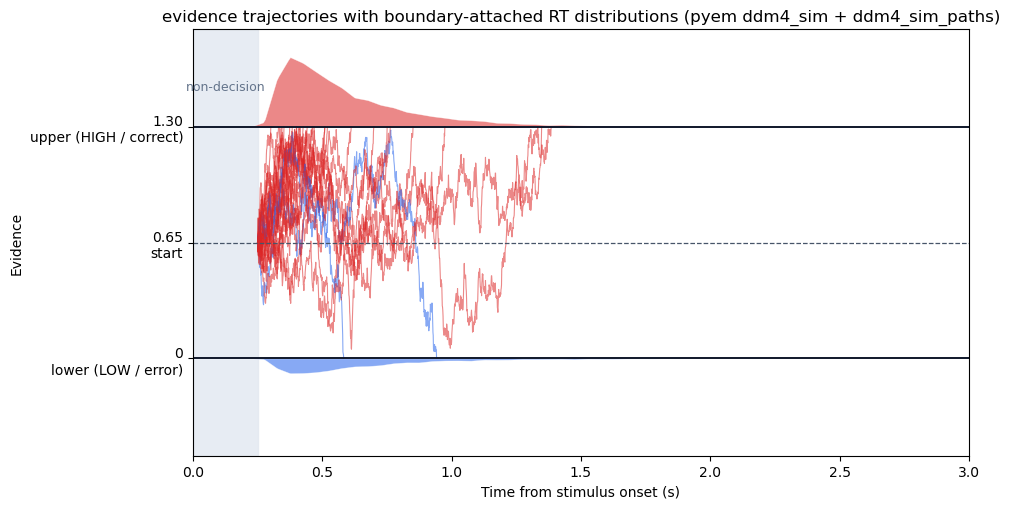

P(correct/HIGH)=0.798, P(error/LOW)=0.202, paths crossed: 25/25


In [ ]:
pars_vis = dict(v_coef=1.5, a=1.3, t0=0.25, z=0.5)
vec_vis = np.array([[pars_vis[k] for k in ("v_coef", "a", "t0", "z")]])
a_vis = pars_vis["a"]

dist_vis = ddm4_sim(vec_vis, ntrials=20000, rng=np.random.default_rng(11))    # ribbons (dt=1e-4)
paths = ddm4_sim_paths(vec_vis[0], ntrials=25, dt=1e-3, max_time=4.0,
                       rng=np.random.default_rng(12))                         # trajectories

rt_vis, ch_vis = dist_vis["rt"][0], dist_vis["choice"][0]
path_colors = {1: "#dc2626", 0: "#2563eb"}     # upper=HIGH red, lower=LOW blue

fig, ax = plt.subplots(figsize=(10, 5.2))
t_max = 3.0
ax.axvspan(0, pars_vis["t0"], color="#e2e8f0", alpha=0.8, zorder=0)
ax.text(pars_vis["t0"] / 2, a_vis * 1.16, "non-decision", ha="center", fontsize=9, color="#64748b")

grid = np.linspace(0, t_max, 400)
ribbon = {}
for key, cval in (("upper", 1), ("lower", 0)):
    rts = rt_vis[ch_vis == cval]
    hist, edges = np.histogram(rts, bins=60, range=(0, t_max), density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    ribbon[key] = np.interp(grid, centers, hist) * (rts.size / rt_vis.size)
height_scale = 0.30 * a_vis / max(ribbon["upper"].max(), ribbon["lower"].max())
ax.fill_between(grid, a_vis, a_vis + ribbon["upper"] * height_scale,
                color="#dc2626", alpha=0.55, lw=0.4, edgecolor="white")
ax.fill_between(grid, -ribbon["lower"] * height_scale, 0.0,
                color="#2563eb", alpha=0.55, lw=0.4, edgecolor="white")

for t_path, x_path, ch, cr in zip(paths["t"], paths["x"], paths["choice"], paths["crossed"]):
    ax.plot(t_path, x_path, color=path_colors[int(ch)] if cr else "#64748b", alpha=0.55, lw=0.8)

ax.axhline(0, color="#0f172a", lw=1.4)
ax.axhline(a_vis, color="#0f172a", lw=1.4)
ax.axhline(pars_vis["z"] * a_vis, color="#475569", lw=0.9, ls="--")
ax.set_yticks([0, pars_vis["z"] * a_vis, a_vis])
ax.set_yticklabels(["0\nlower (LOW / error)", f"{pars_vis['z'] * a_vis:.2f}\nstart",
                    f"{a_vis:.2f}\nupper (HIGH / correct)"])
ax.set_xlim(0, t_max); ax.set_ylim(-0.42 * a_vis, 1.42 * a_vis)
ax.set_xlabel("Time from stimulus onset (s)"); ax.set_ylabel("Evidence")
ax.set_title("evidence trajectories with boundary-attached RT distributions")
plt.tight_layout(); plt.show()

print(f"P(correct/HIGH)={np.mean(ch_vis == 1):.3f}, P(error/LOW)={np.mean(ch_vis == 0):.3f}, "
      f"paths crossed: {int(paths['crossed'].sum())}/25")

### References

- Navarro, D. J., & Fuss, I. G. (2009). Fast and accurate calculations for
  first-passage times in Wiener diffusion models. *Journal of Mathematical
  Psychology*, 53(4), 222-230.
- Ratcliff, R., & Rouder, J. N. (1998). Modeling response times for two-choice
  decisions. *Psychological Science*, 9(5), 347-356.
- Ratcliff, R., & Tuerlinckx, F. (2002). Estimating parameters of the diffusion
  model. *Psychonomic Bulletin & Review*, 9(3), 438-481.
- Ratcliff, R., & McKoon, G. (2008). The diffusion decision model: Theory and data
  for two-choice decision tasks. *Neural Computation*, 20(4), 873-922.
- Henrich, F., Hartmann, R., Pratz, V., Voss, A., & Klauer, K. C. (2024). The
  seven-parameter diffusion model: An implementation in Stan for Bayesian analyses.
  *Behavior Research Methods*, 56, 3102-3116.
- Hartmann, R., & Klauer, K. C. (2021). Partial derivatives for the first-passage time
  distribution in Wiener diffusion models. *Journal of Mathematical Psychology*, 103,
  102550.

The cross-validation reference implementation (R/Shiny visualiser) lives at
`references/index.qmd`. The four-parameter models (`ddm4`, `ddm4_lotto`) are
available in `pyem.models.ddm`; the seven-parameter models (`ddm7`, `ddm7_lotto`)
are not supported in this release yet.
